In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [40]:
data = pd.read_csv("diabetes.csv")


In [41]:
data.head()
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [42]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [44]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [45]:
y_pred = model.predict(X_test)


In [46]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.7402597402597403


<Axes: >

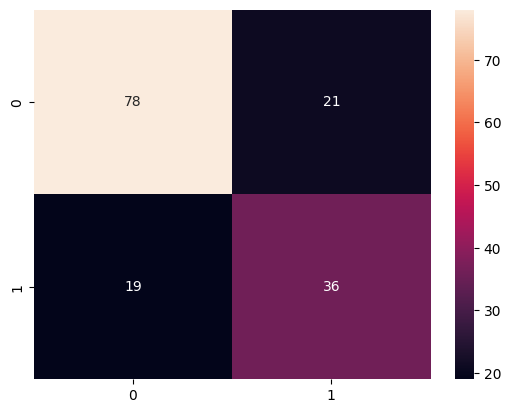

In [47]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


In [49]:
lr = LogisticRegression()
rf = RandomForestClassifier()
svm = SVC()

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
svm.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


SVC()

In [50]:
print("LR:", lr.score(X_test, y_test))
print("RF:", rf.score(X_test, y_test))
print("SVM:", svm.score(X_test, y_test))


LR: 0.7402597402597403
RF: 0.7402597402597403
SVM: 0.7662337662337663


In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [55]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

In [56]:
def get_user_input():
    pregnancies = int(input("Enter Pregnancies: "))
    glucose = float(input("Enter Glucose Level: "))
    bp = float(input("Enter Blood Pressure: "))
    skin = float(input("Enter Skin Thickness: "))
    insulin = float(input("Enter Insulin Level: "))
    bmi = float(input("Enter BMI: "))
    dpf = float(input("Enter Diabetes Pedigree Function: "))
    age = int(input("Enter Age: "))

    return np.array([[pregnancies, glucose, bp, skin, insulin, bmi, dpf, age]])


In [61]:
user_data = get_user_input()
user_df = pd.DataFrame(user_data, columns=X.columns)

prediction = rf.predict(user_df)
if prediction[0] == 1:
    disease = "Diabetes Detected"
else:
    disease = "No Diabetes Detected"


Enter Pregnancies: 0
Enter Glucose Level: 145
Enter Blood Pressure: 85
Enter Skin Thickness: 35
Enter Insulin Level: 120
Enter BMI: 32
Enter Diabetes Pedigree Function: 0.43
Enter Age: 42


In [62]:
def risk_level(glucose, bp, bmi):
    if glucose < 140 and bp < 120 and bmi < 25:
        return "Level 1 – Normal (Safe Zone)"
    elif glucose < 200 and bp < 140:
        return "Level 2 – Warning (Need Medical Care)"
    else:
        return "Level 3 – Dangerous (Immediate Attention Required)"


In [63]:
def health_advice(level):
    if "Level 1" in level:
        return "Maintain a balanced diet and regular physical activity."
    elif "Level 2" in level:
        return "Reduce sugar intake, exercise daily, and consult a doctor."
    else:
        return "Seek immediate medical consultation. Continuous monitoring required."


In [64]:
glucose = user_df["Glucose"].values[0]
bp = user_df["BloodPressure"].values[0]
bmi = user_df["BMI"].values[0]

level = risk_level(glucose, bp, bmi)
advice = health_advice(level)

print("\n--- HEALTH ASSESSMENT REPORT ---")
print("Disease Prediction:", disease)
print("Risk Level:", level)
print("Advice:", advice)



--- HEALTH ASSESSMENT REPORT ---
Disease Prediction: Diabetes Detected
Risk Level: Level 2 – Warning (Need Medical Care)
Advice: Reduce sugar intake, exercise daily, and consult a doctor.


In [65]:
def bp_status(bp):
    if bp < 120:
        return "Normal Blood Pressure"
    elif bp < 140:
        return "Elevated Blood Pressure"
    else:
        return "High Blood Pressure (Hypertension)"


In [66]:
def heart_risk(age, bp, bmi):
    if age < 40 and bp < 130 and bmi < 25:
        return "Low Heart Disease Risk"
    elif age < 60 and bp < 140:
        return "Moderate Heart Disease Risk"
    else:
        return "High Heart Disease Risk"


In [67]:
bp_result = bp_status(bp)
heart_result = heart_risk(
    user_df["Age"].values[0],
    bp,
    bmi
)


In [68]:
print("\n--- COMPLETE HEALTH ASSESSMENT ---")
print("Diabetes Status:", disease)
print("Blood Pressure Status:", bp_result)
print("Heart Risk Assessment:", heart_result)
print("Risk Level:", level)
print("Advice:", advice)



--- COMPLETE HEALTH ASSESSMENT ---
Diabetes Status: Diabetes Detected
Blood Pressure Status: Normal Blood Pressure
Heart Risk Assessment: Moderate Heart Disease Risk
Risk Level: Level 2 – Warning (Need Medical Care)
Advice: Reduce sugar intake, exercise daily, and consult a doctor.


PDF HEALTH REPORT GENERATION

In [69]:
!pip install reportlab


In [70]:
from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas

def generate_pdf_report(data):
    file_name = "Health_Report.pdf"
    c = canvas.Canvas(file_name, pagesize=letter)
    text = c.beginText(40, 750)

    for line in data:
        text.textLine(line)

    c.drawText(text)
    c.save()

    return file_name


In [71]:
report_data = [
    "SMART HEALTH RISK ASSESSMENT REPORT",
    "----------------------------------",
    f"Disease Prediction: {disease}",
    f"Blood Pressure Status: {bp_result}",
    f"Heart Risk Assessment: {heart_result}",
    f"Risk Level: {level}",
    f"Health Advice: {advice}",
    "",
    "Note: This report is generated for academic purposes only."
]


In [72]:
pdf_file = generate_pdf_report(report_data)
print("PDF Report Generated Successfully:", pdf_file)


PDF Report Generated Successfully: Health_Report.pdf


In [74]:
from google.colab import files
files.download(pdf_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>